# Data Loading and Preprocessing

In [1]:
# This cells setups the environment when executed in Google Colab.
try:
    import google.colab
    !curl -s https://raw.githubusercontent.com/ibs-lab/cedalion/dev/scripts/colab_setup.py -o colab_setup.py
    # Select branch with --branch "branch name" (default is "dev")
    %run colab_setup.py
except ImportError:
    pass

In [2]:
import matplotlib.pyplot as p
import numpy as np

import cedalion
import cedalion.data
import cedalion.sigproc.motion as motion
import cedalion.sigproc.quality as quality
import cedalion.vis.blocks as vbx
import cedalion.vis.colors as colors
from cedalion.vis.anatomy import scalp_plot
from cedalion.vis.quality import plot_quality_mask
from cedalion import units
from cedalion.vis.anatomy import plot_montage3D

## Load Data

Example datasets are accessible through functions in `cedalion.data`. These take care of downloading, caching and updating the data files. Often they also already load the data.

Here we load a single-subject DOT dataset with a motor task.

In [3]:
# rec = cedalion.data.get_fingertappingDOT()
rec = cedalion.io.read_snirf(r"D:\WorkPy\04_data_mainstudy\measurement_01\2025-05-03_001\2025-05-03_001_cut.snirf")[0]
rec

<Recording |  timeseries: ['amp'],  masks: [],  stim: [],  aux_ts: ['ACCEL_X', 'ACCEL_Y', 'ACCEL_Z', 'GYRO_X', 'GYRO_Y', 'GYRO_Z', 'Respiration', 'Temperature', 'GSR', 'PPG', 'SpO2', 'Heartrate'],  aux_obj: []>

This recording object hold a single NIRS time series `'amp'`

In [4]:
rec.timeseries.keys()

odict_keys(['amp'])

It contains several auxiliary time series from additional sensors:

In [5]:
rec.aux_ts.keys()

odict_keys(['ACCEL_X', 'ACCEL_Y', 'ACCEL_Z', 'GYRO_X', 'GYRO_Y', 'GYRO_Z', 'Respiration', 'Temperature', 'GSR', 'PPG', 'SpO2', 'Heartrate'])

## Inspecting the Datasets

### Raw Amplitude Time Series

In [6]:
rec["amp"]

Magnitude,[[[547.23078 548.00554 548.95076 ... 519.04287 519.55126 519.9789] [575.06075 576.53964 577.60599 ... 539.4500499999999 540.21907 540.9374799999999]] [[140.30824 140.38849 140.51447 ... 133.22006000000002 133.13779000000002 133.36115] [154.77662 155.07509 155.07919 ... 145.74093 146.00812 146.17665]] [[0.25195 0.25301 0.25390999999999997 ... 0.27014 0.27726 0.26337] [0.26634 0.25964 0.26436000000000004 ... 0.26407 0.26987 0.26341000000000003]] ... [[0.010320000000000001 0.010480000000000001 0.010360000000000001 ... 0.01352 0.01324 0.0135] [0.0301 0.0298 0.02904 ... 0.03698 0.03604 0.0369]] [[228.29853 228.96151 229.13838 ... 226.9353 227.0041 227.37387] [495.07091 496.26137 497.69778 ... 474.35484 475.29696 476.26755]] [[241.47747 241.21294 240.97748 ... 265.58052 265.1587 265.07376] [608.25401 608.8115 608.87212 ... 644.9378499999999 645.20112 645.59745]]]
Units,dimensionless


### Stimulus event information

In [7]:
rec.stim

,onset,duration,value,trial_type


### Montage

In [8]:
rec.geo3d

Magnitude,[[-0.235 62.434 65.513] [-35.609 78.819 16.092] [-29.23 85.182 -14.189] ... [77.521 28.883 -39.113] [80.59 14.229 -38.278] [81.95 -0.678 -37.027]]
Units,millimeter


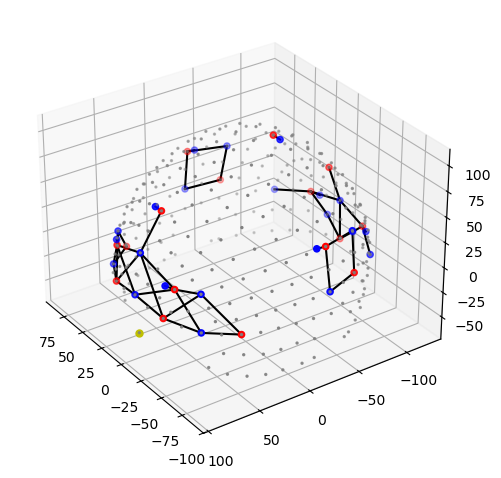

In [9]:
plot_montage3D(rec["amp"], rec.geo3d)

### Channel Distances

Text(0, 0.5, 'channel count')

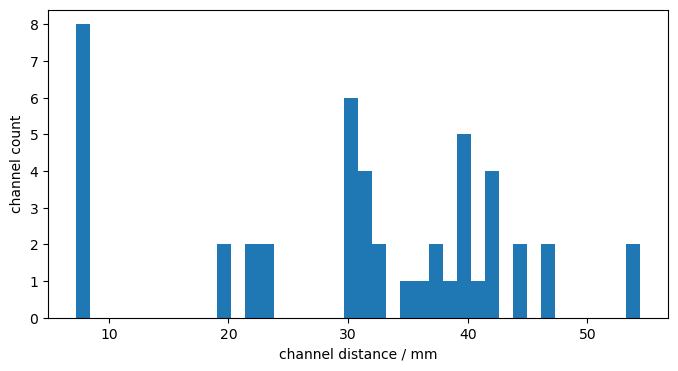

In [10]:
distances = cedalion.nirs.channel_distances(rec["amp"], rec.geo3d)

p.figure(figsize=(8,4))
p.hist(distances, 40)
p.xlabel("channel distance / mm")
p.ylabel("channel count")

### Plot raw amplitude for one channel

Text(0.5, 1.0, 'S1D15')

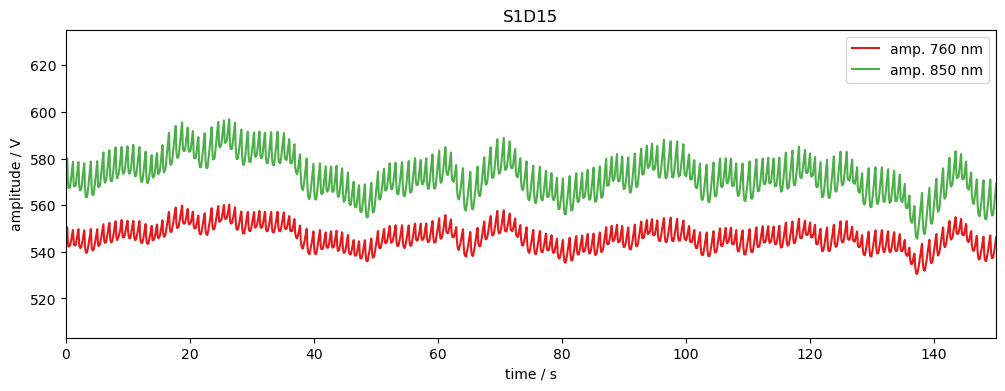

In [11]:
# example time trace
amp = rec["amp"]
ch = "S1D15"
f, ax = p.subplots(1,1, figsize=(12,4))
ax.set_prop_cycle("color", colors.COLORBREWER_Q8)
ax.plot(amp.time, amp.sel(channel=ch, wavelength=760), label="amp. 760 nm")
ax.plot(amp.time, amp.sel(channel=ch, wavelength=850), label="amp. 850 nm")
vbx.plot_stim_markers(ax, rec.stim, y=1)
ax.set_xlabel("time / s")
ax.set_ylabel("amplitude / V")
ax.set_xlim(0,150)
ax.legend()
ax.set_title(ch)

## Quality Metrics : SCI & PSP

- using functions from cedalion.sigproc.quality we calculate two metrics:
  - scalp coupling index (SCI) 
  - peak spectral power (PSP)

- note the different time axis: both metrics a calculated in sliding windows 
- both functions return a metric and boolean arrays (masks) if the metric is above threshold

In [12]:
sci_threshold = 0.75
window_length = 10*units.s
sci, sci_mask = quality.sci(rec["amp"], window_length, sci_threshold)

psp_threshold = 0.03
psp, psp_mask = quality.psp(rec["amp"], window_length, psp_threshold)


display(sci.rename("sci"))
display(sci_mask.rename("sci_mask"))


<xarray.DataArray 'sci' (channel: 47, time: 147)> Size: 55kB
array([[ 0.99956369,  0.99956369,  0.9997058 , ...,  0.99960563,
         0.99946424,  0.99940145],
       [ 0.99814017,  0.99814017,  0.9969997 , ...,  0.99771858,
         0.99691471,  0.99734685],
       [ 0.72777165,  0.72777165,  0.4433033 , ...,  0.40781169,
         0.29654447,  0.26756344],
       ...,
       [ 0.4434155 ,  0.4434155 ,  0.25996881, ...,  0.24821109,
        -0.1081024 , -0.09894493],
       [ 0.99696938,  0.99696938,  0.99693292, ...,  0.99836762,
         0.99667198,  0.99731571],
       [ 0.5123532 ,  0.5123532 ,  0.4728762 , ...,  0.13626689,
         0.20233839,  0.08749154]], shape=(47, 147))
Coordinates:
  * time      (time) float64 1kB 0.0 10.02 20.04 ... 1.453e+03 1.463e+03
    samples   (time) int64 1kB 0 202 404 606 808 ... 28886 29088 29290 29492
  * channel   (channel) object 376B 'S1D15' 'S1D16' 'S2D1' ... 'S16D12' 'S16D23'
    source    (channel) object 376B 'S1' 'S1' 'S2' 'S2' ... 'S16' 'S16' 'S16'
    detector  (channel) object 376B 'D15' 'D16' 'D1' 'D2' ... 'D8' 'D12' 'D23'

<xarray.DataArray 'sci_mask' (channel: 47, time: 147)> Size: 7kB
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False]], shape=(47, 147))
Coordinates:
  * time      (time) float64 1kB 0.0 10.02 20.04 ... 1.453e+03 1.463e+03
    samples   (time) int64 1kB 0 202 404 606 808 ... 28886 29088 29290 29492
  * channel   (channel) object 376B 'S1D15' 'S1D16' 'S2D1' ... 'S16D12' 'S16D23'
    source    (channel) object 376B 'S1' 'S1' 'S2' 'S2' ... 'S16' 'S16' 'S16'
    detector  (channel) object 376B 'D15' 'D16' 'D1' 'D2' ... 'D8' 'D12' 'D23'

In [13]:
# define three colomaps: redish below a threshold, blueish above
sci_norm, sci_cmap = colors.threshold_cmap("sci_cmap", 0., 1.0, sci_threshold) 
psp_norm, psp_cmap = colors.threshold_cmap("psp_cmap", 0., 0.30, psp_threshold)

def plot_sci(sci):
    # plot the heatmap
    f,ax = p.subplots(1,1,figsize=(12,10))

    m = ax.pcolormesh(sci.time, np.arange(len(sci.channel)), sci, shading="nearest", cmap=sci_cmap, norm=sci_norm)
    cb = p.colorbar(m, ax=ax)
    cb.set_label("SCI")
    ax.set_xlabel("time / s")
    p.tight_layout()
    ax.yaxis.set_ticks(np.arange(len(sci.channel)))
    ax.yaxis.set_ticklabels(sci.channel.values, fontsize=7)

def plot_psp(psp):
    f,ax = p.subplots(1,1,figsize=(12,10))

    m = ax.pcolormesh(psp.time, np.arange(len(psp.channel)), psp, shading="nearest", cmap=psp_cmap, norm=psp_norm)
    cb = p.colorbar(m, ax=ax)
    cb.set_label("PSP")
    ax.set_xlabel("time / s")
    p.tight_layout()
    ax.yaxis.set_ticks(np.arange(len(psp.channel)))
    ax.yaxis.set_ticklabels(psp.channel.values, fontsize=7)



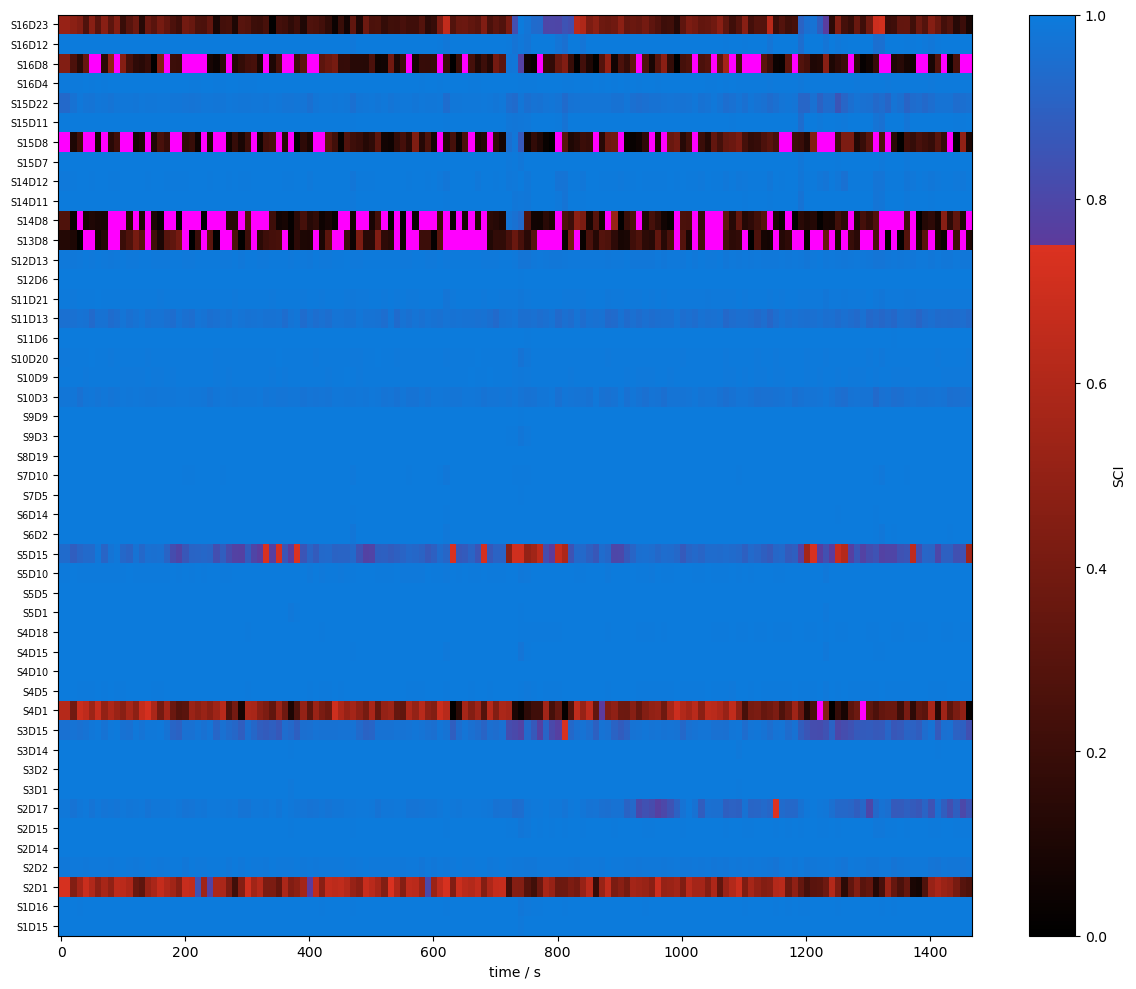

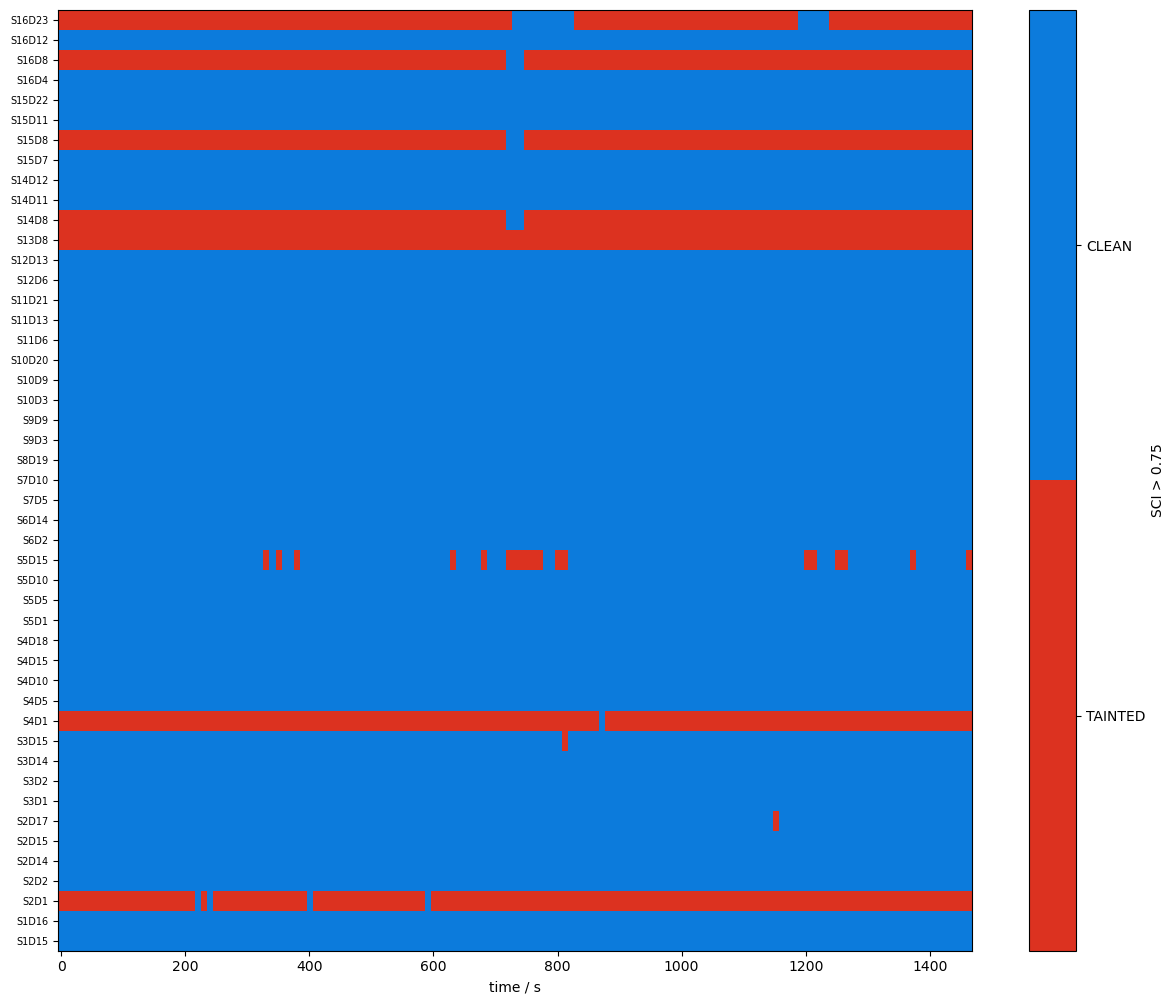

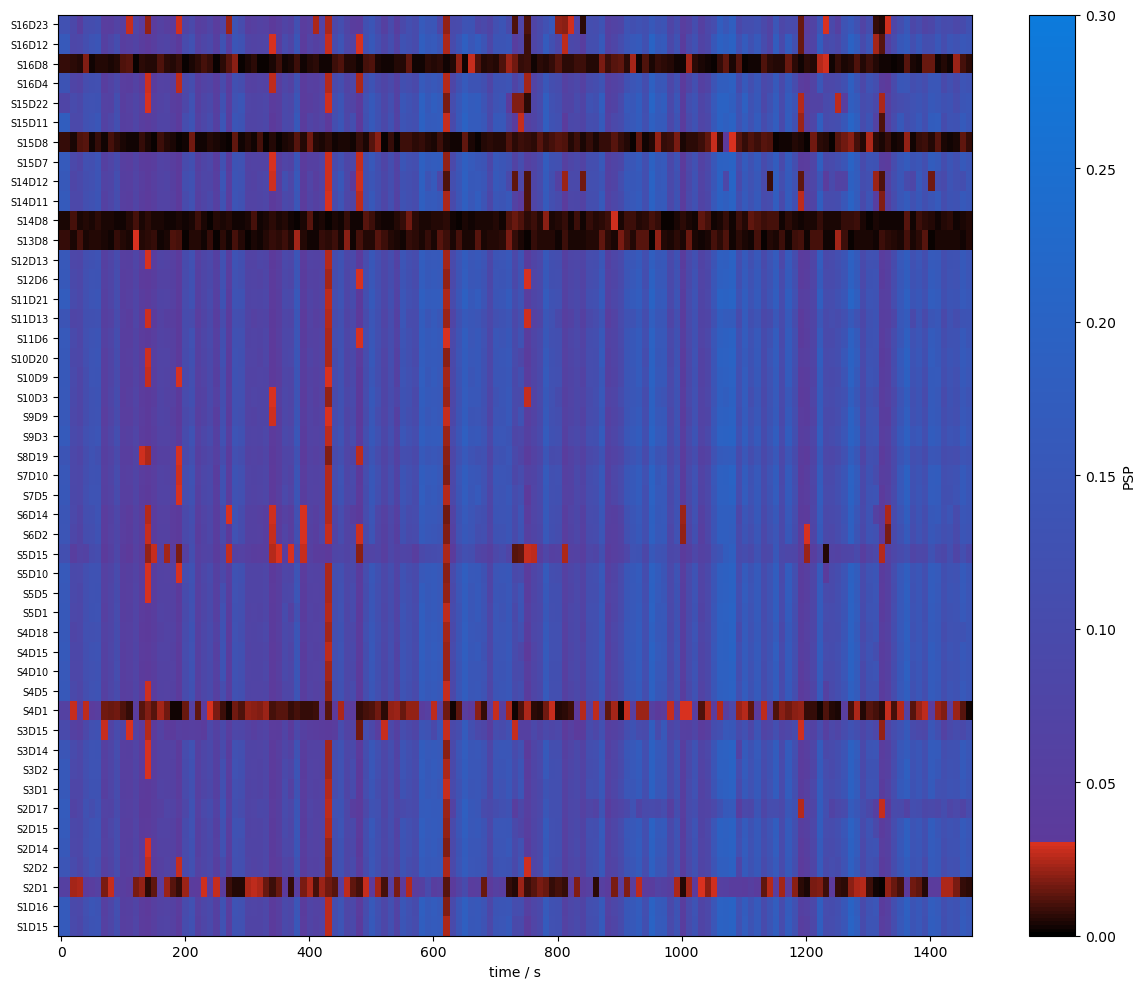

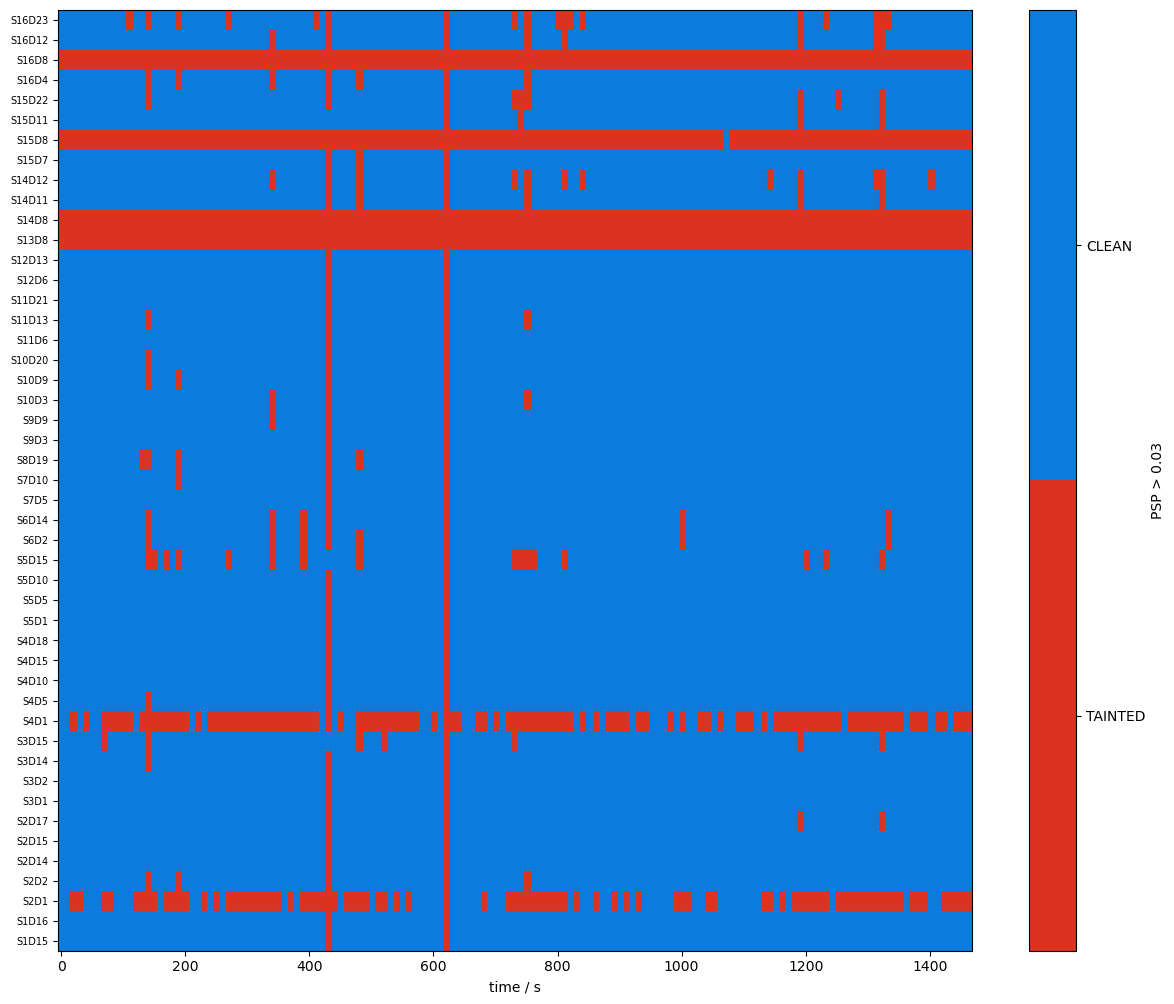

In [14]:
plot_sci(sci)
plot_quality_mask(sci > sci_threshold, f"SCI > {sci_threshold}")
plot_psp(psp)
plot_quality_mask(psp > psp_threshold, f"PSP > {psp_threshold}")

## Combining Signal Quality Masks

We want both SCI and PSP to be above their respective thresholds for a window to be considered clean. We can use the boolean and operation to combine both and then look at the percentage of time both metrics are above the thresholds.

<xarray.DataArray (channel: 47, time: 147)> Size: 7kB
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False]], shape=(47, 147))
Coordinates:
  * time      (time) float64 1kB 0.0 10.02 20.04 ... 1.453e+03 1.463e+03
    samples   (time) int64 1kB 0 202 404 606 808 ... 28886 29088 29290 29492
  * channel   (channel) object 376B 'S1D15' 'S1D16' 'S2D1' ... 'S16D12' 'S16D23'
    source    (channel) object 376B 'S1' 'S1' 'S2' 'S2' ... 'S16' 'S16' 'S16'
    detector  (channel) object 376B 'D15' 'D16' 'D1' 'D2' ... 'D8' 'D12' 'D23'

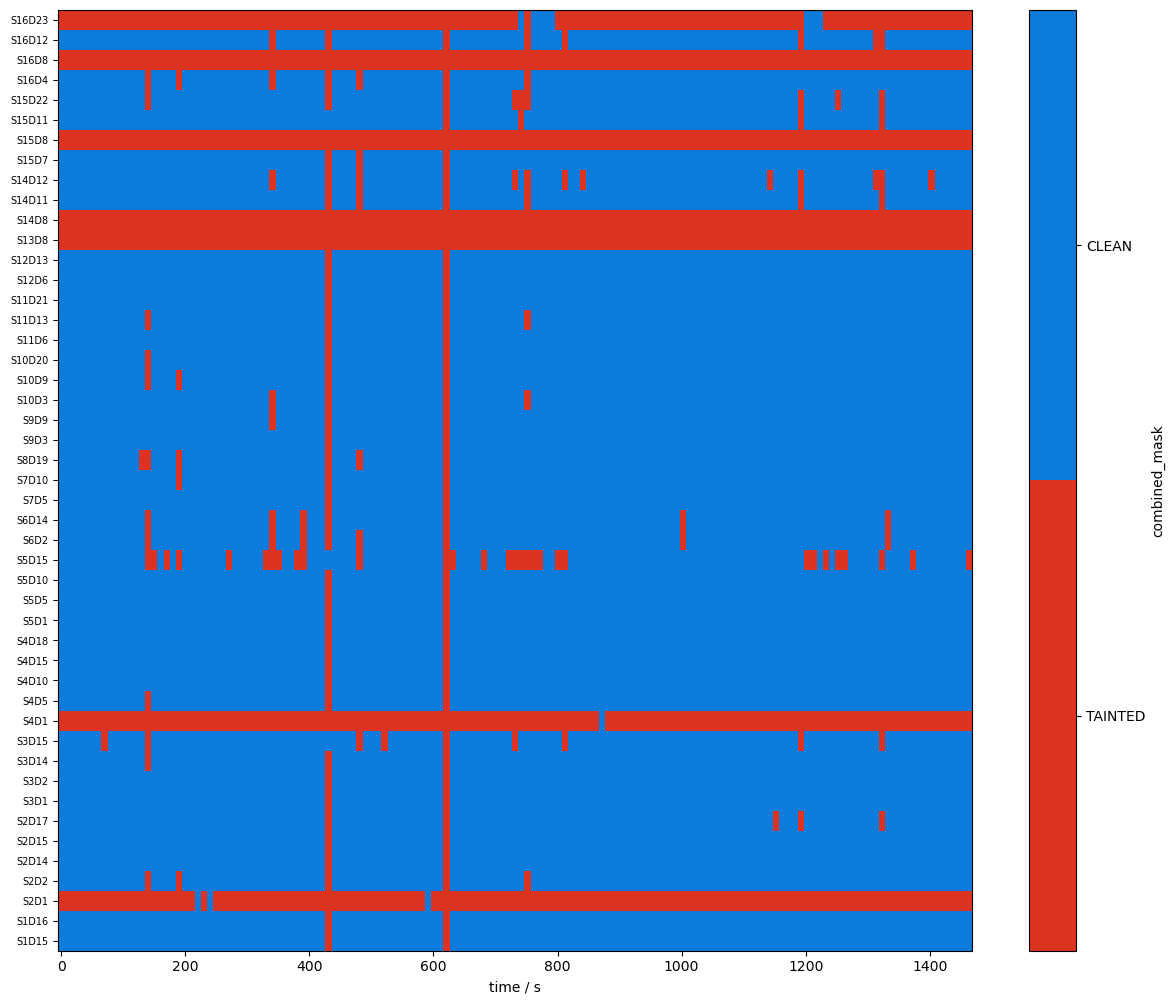

In [15]:
combined_mask = sci_mask & psp_mask

display(combined_mask)
plot_quality_mask(combined_mask, "combined_mask")

- calculate percentage of clean time per channel

<xarray.DataArray (channel: 47)> Size: 376B
array([0.98639456, 0.98639456, 0.02040816, 0.96598639, 0.98639456,
       0.98639456, 0.96598639, 0.98639456, 0.98639456, 0.97959184,
       0.93877551, 0.00680272, 0.97959184, 0.98639456, 0.98639456,
       0.98639456, 0.98639456, 0.98639456, 0.98639456, 0.79591837,
       0.94557823, 0.95238095, 0.98639456, 0.97959184, 0.95918367,
       0.98639456, 0.97959184, 0.97278912, 0.97278912, 0.97959184,
       0.98639456, 0.97278912, 0.98639456, 0.98639456, 0.98639456,
       0.        , 0.        , 0.95918367, 0.91156463, 0.97959184,
       0.        , 0.97278912, 0.93877551, 0.95238095, 0.        ,
       0.94557823, 0.05442177])
Coordinates:
  * channel   (channel) object 376B 'S1D15' 'S1D16' 'S2D1' ... 'S16D12' 'S16D23'
    source    (channel) object 376B 'S1' 'S1' 'S2' 'S2' ... 'S16' 'S16' 'S16'
    detector  (channel) object 376B 'D15' 'D16' 'D1' 'D2' ... 'D8' 'D12' 'D23'

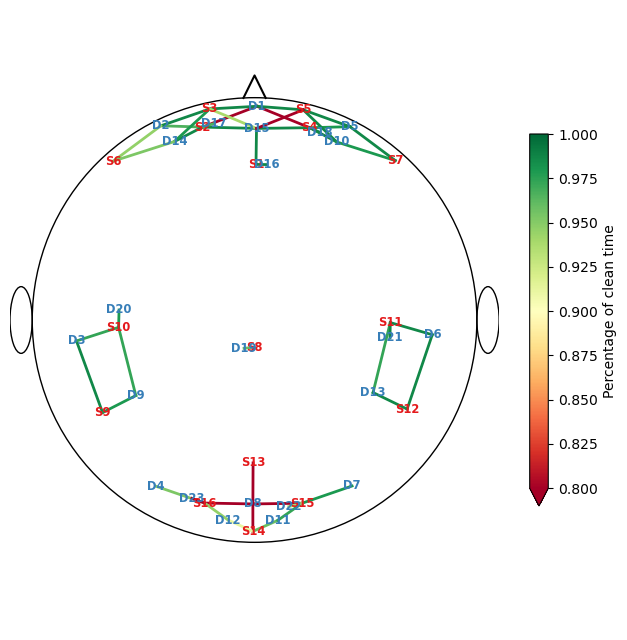

In [16]:
perc_time_clean = combined_mask.sum(dim="time") / len(sci.time)

display(perc_time_clean)

f, ax = p.subplots(1,1,figsize=(6.5,6.5))

scalp_plot(
    rec["amp"],
    rec.geo3d,
    perc_time_clean,
    ax,
    cmap="RdYlGn",
    vmin=0.80,
    vmax=1,
    title=None,
    cb_label="Percentage of clean time",
    channel_lw=2,
    optode_labels=True
)
f.tight_layout()

## Correct Motion Artefacts
- use `cedalion.nirs.cw.int2od` to get optical densities
- apply Temporal Derivative Distribution Repair (TDDR) first to correct jumps 
- then apply Wavelet motion artifact correction

In [17]:
rec["od"] = cedalion.nirs.cw.int2od(rec["amp"])
rec["od_tddr"] = motion.tddr(rec["od"])
rec["od_wavelet"] = motion.wavelet(rec["od_tddr"])
rec["amp_corrected"] = cedalion.nirs.cw.od2int(rec["od_wavelet"], rec["amp"].mean("time"))


In [18]:
# recalculate sci & psp on cleaned data
sci_corr, sci_corr_mask = quality.sci(rec["amp_corrected"], window_length, sci_threshold)
psp_corr, psp_corr_mask = quality.psp(rec["amp_corrected"], window_length, psp_threshold)
combined_corr_mask = sci_corr_mask & psp_corr_mask

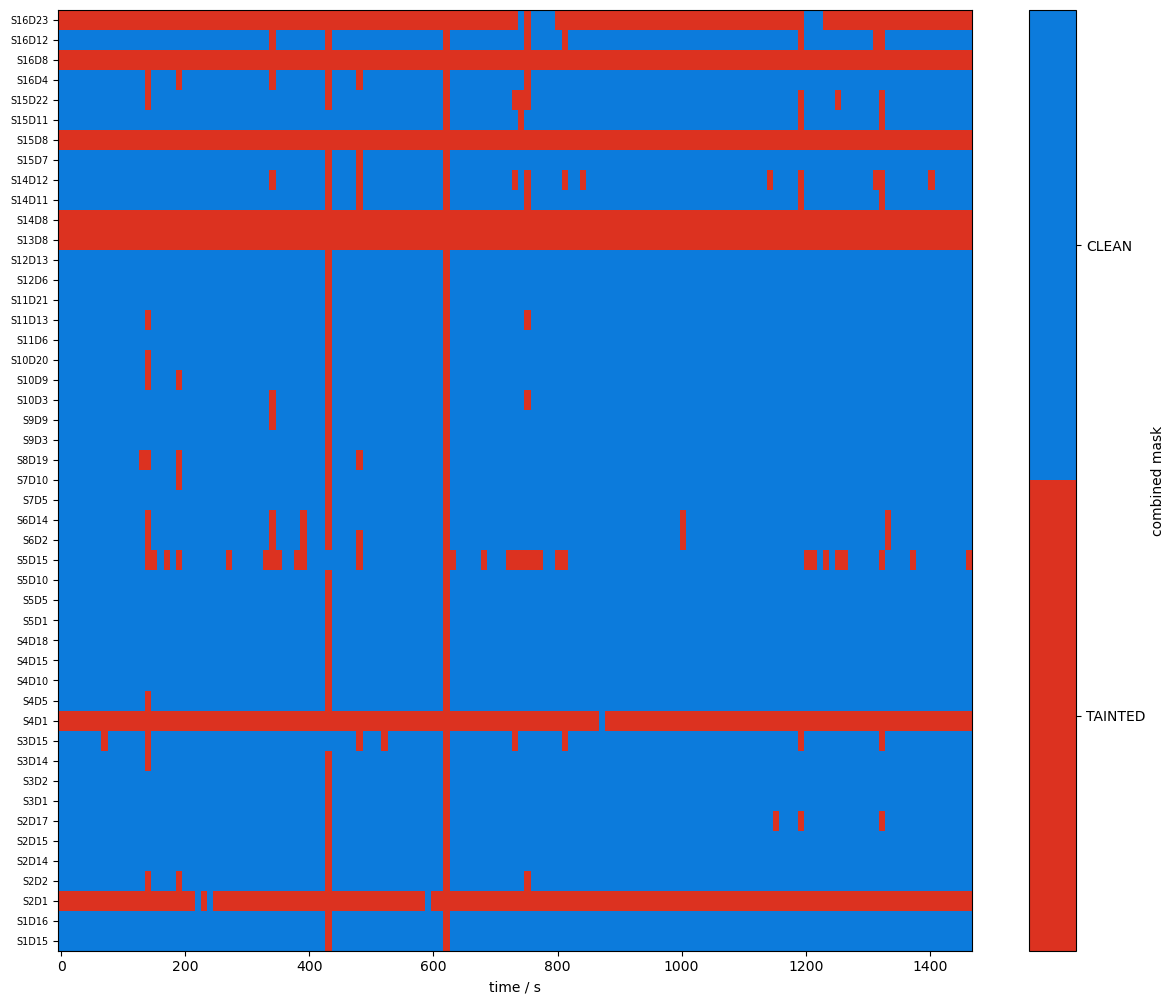

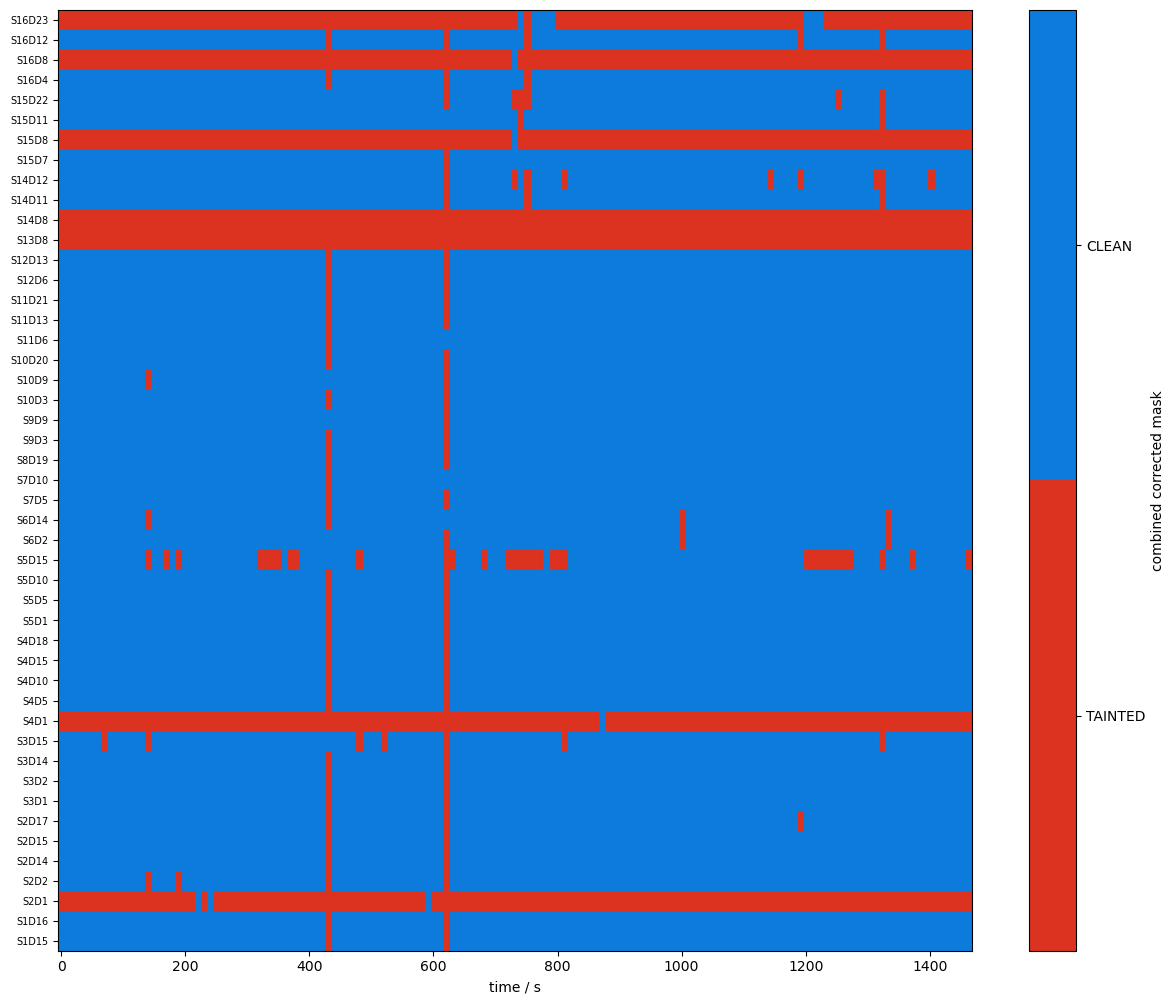

In [19]:
plot_quality_mask(combined_mask, f"combined mask")
plot_quality_mask(combined_corr_mask, f"combined corrected mask")

## Compare masks before and after motion artifact correction

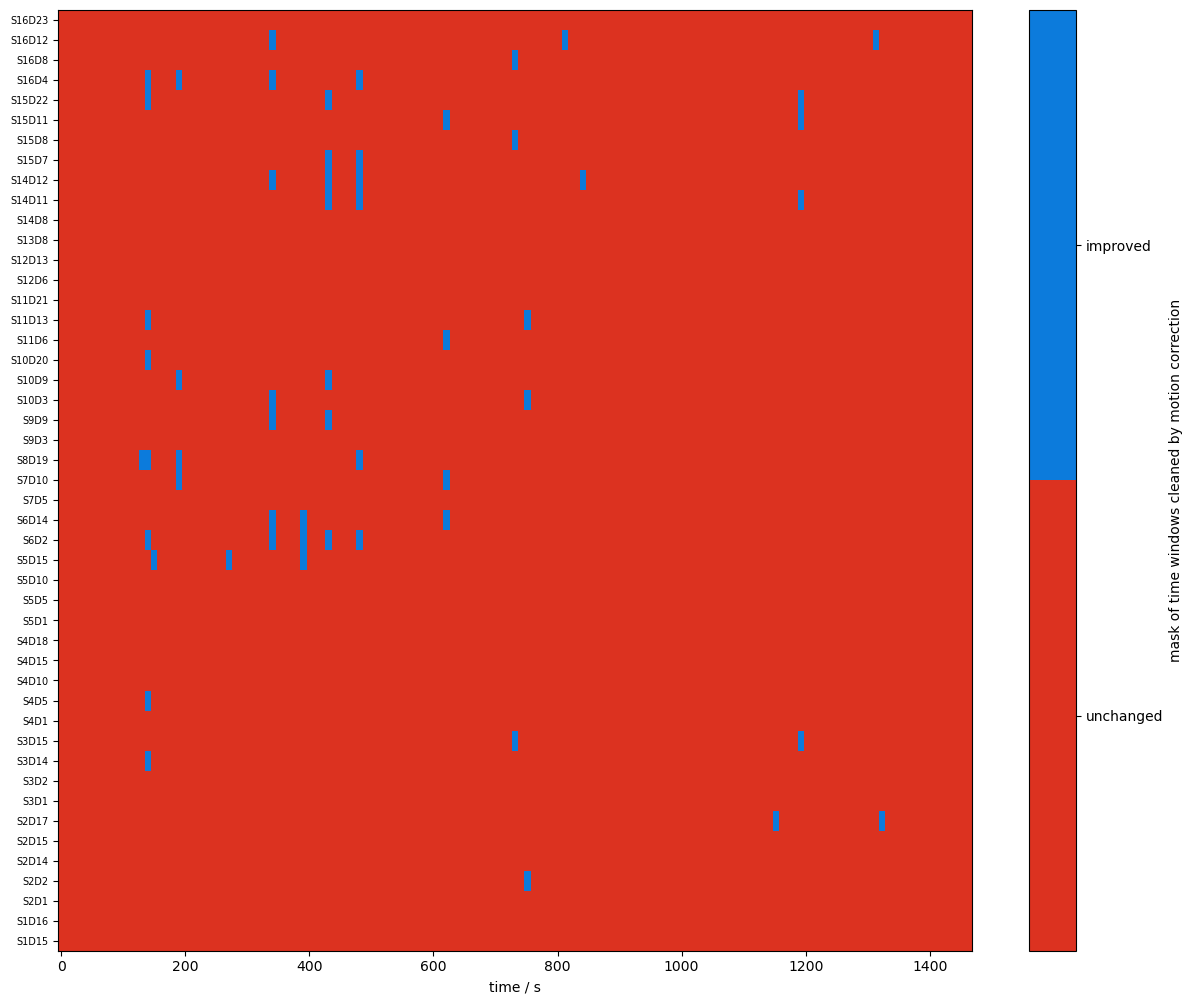

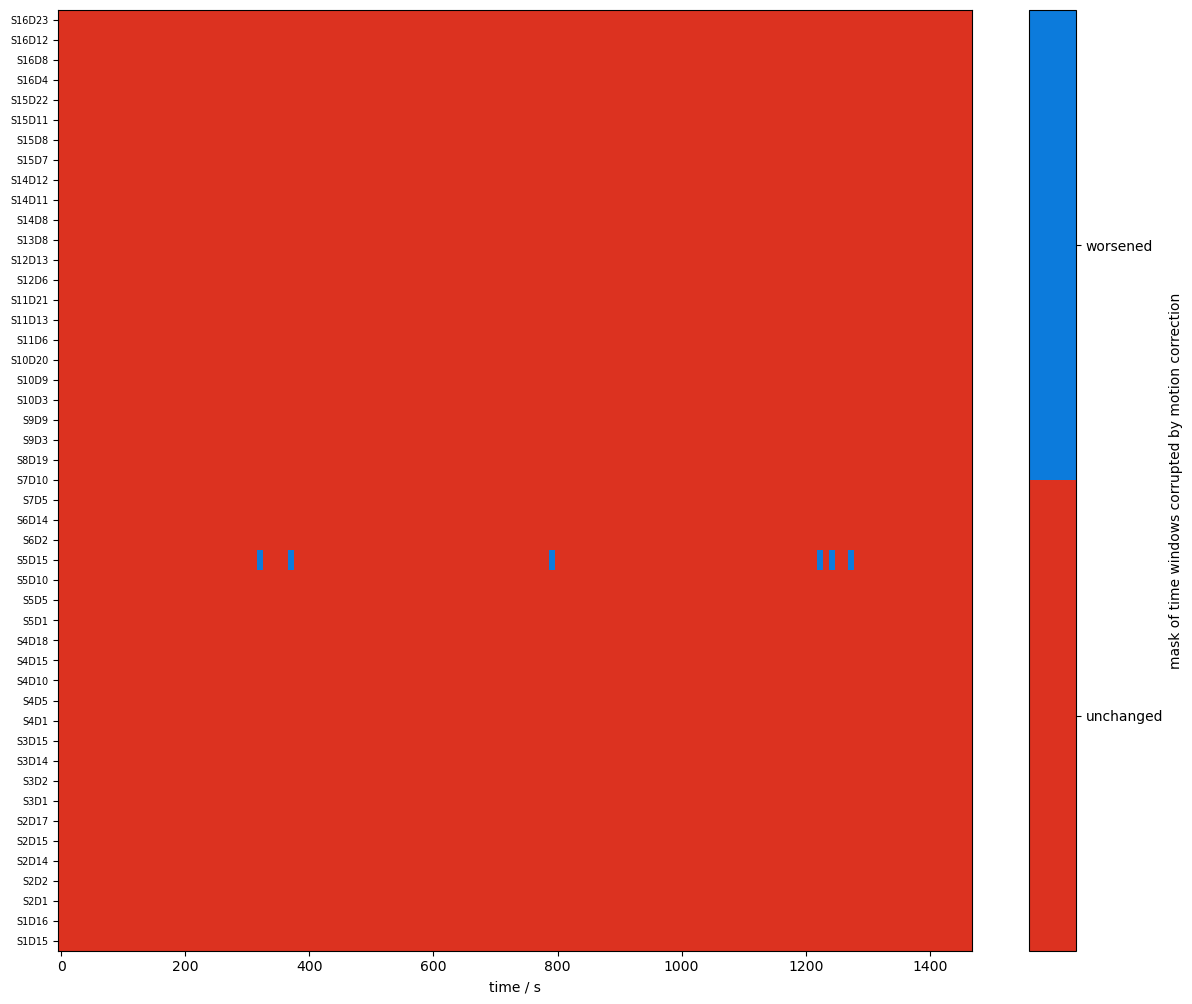

In [20]:
changed_windows = (combined_mask == quality.TAINTED) & (combined_corr_mask == quality.CLEAN)

plot_quality_mask(changed_windows, "mask of time windows cleaned by motion correction", bool_labels=["unchanged", "improved"])

changed_windows = (combined_mask == quality.CLEAN) & (combined_corr_mask == quality.TAINTED)

plot_quality_mask(changed_windows, "mask of time windows corrupted by motion correction", bool_labels=["unchanged", "worsened"])

recalculate percentage of clean time

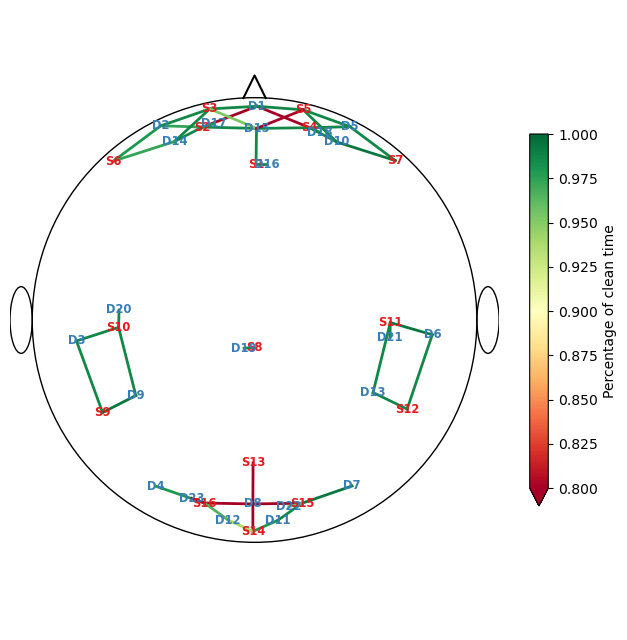

In [21]:
perc_time_clean_corr = combined_corr_mask.sum(dim="time") / len(sci.time)

f, ax = p.subplots(1,1,figsize=(6.5,6.5))

scalp_plot(
    rec["amp"],
    rec.geo3d,
    perc_time_clean_corr,
    ax,
    cmap="RdYlGn",
    vmin=0.80,
    vmax=1,
    title=None,
    cb_label="Percentage of clean time",
    channel_lw=2,
    optode_labels=True
)
f.tight_layout()

## Global Variance of the Temporal Derivative (GVTD) for identifying global bad time segments

In [22]:
gvtd, gvtd_mask = quality.gvtd(rec["amp"])
gvtd_corr, gvtd_prr_mask = quality.gvtd(rec["amp_corrected"])

In [23]:
# select the 10 segments with highest gvtd
top10_bad_segments = sorted(
    [seg for seg in quality.mask_to_segments(combined_mask.all("channel"))],
    key=lambda t: gvtd.sel(time=slice(t[0], t[1])).max(),
    reverse=True,
)[:10]


Calculate GVTD for the original and corrected time series

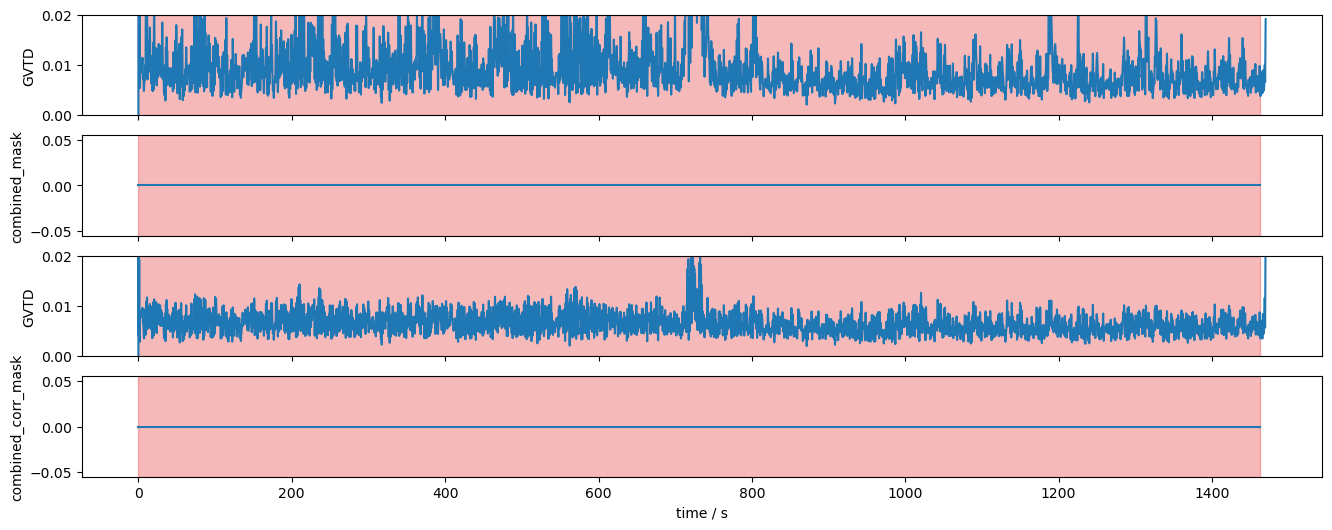

In [24]:
f,ax = p.subplots(4,1,figsize=(16,6), sharex=True)
ax[0].plot(gvtd.time, gvtd)
ax[1].plot(combined_mask.time, combined_mask.all("channel"))
ax[2].plot(gvtd_corr.time, gvtd_corr)
ax[3].plot(combined_corr_mask.time, combined_corr_mask.all("channel"))
ax[0].set_ylim(0, 0.02)
ax[2].set_ylim(0, 0.02)
ax[0].set_ylabel("GVTD")
ax[2].set_ylabel("GVTD")
ax[1].set_ylabel("combined_mask")
ax[3].set_ylabel("combined_corr_mask")
ax[3].set_xlabel("time / s")

for i in range(4):
    vbx.plot_segments(ax[i], top10_bad_segments)


## Highlight motion correction in selected segments

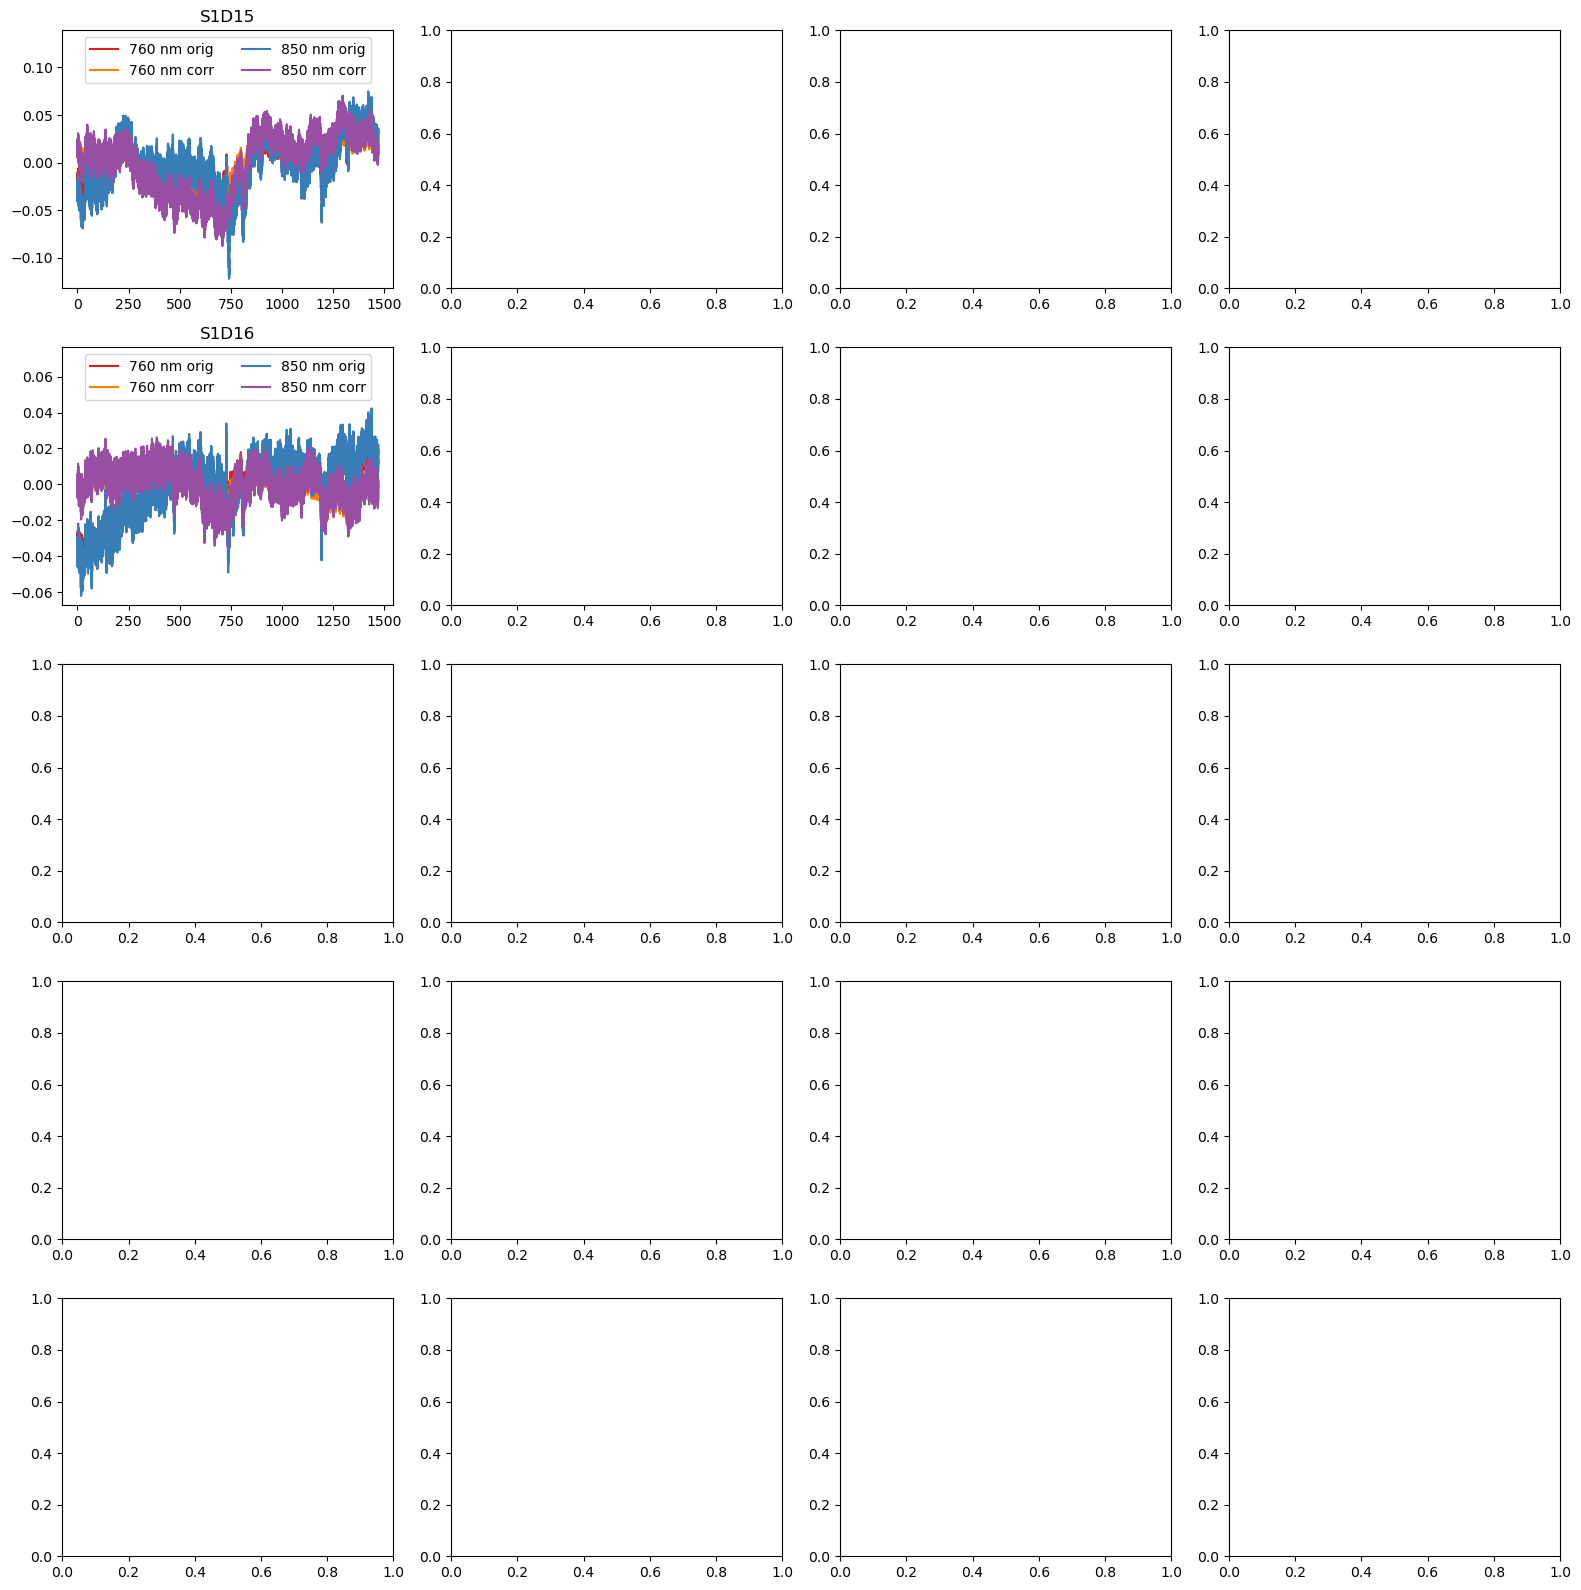

In [25]:
example_channels = ["S1D15", "S1D16"]

f, ax = p.subplots(5,4, figsize=(16,16), sharex=False)
ax = ax.T.flatten()
padding = 15
i = 0
for ch in example_channels:
    for (start, end) in top10_bad_segments:
        ax[i].set_prop_cycle(color=["#e41a1c", "#ff7f00", "#377eb8", "#984ea3"])
        for wl in rec["od"].wavelength.values:
            sel = rec["od"].sel(time=slice(start-padding, end+padding), channel=ch, wavelength=wl)
            ax[i].plot(sel.time, sel, label=f"{wl:.0f} nm orig")
            sel = rec["od_wavelet"].sel(time=slice(start-padding, end+padding), channel=ch, wavelength=wl)
            ax[i].plot(sel.time, sel, label=f"{wl:.0f} nm corr")
            ax[i].set_title(ch)
        ax[i].legend(ncol=2, loc="upper center")
        ylim = ax[i].get_ylim()
        ax[i].set_ylim(ylim[0], ylim[1]+0.25*(ylim[1]-ylim[0])) # make space for legend

        i += 1

p.tight_layout()


## Final channel selection

In [26]:
perc_time_clean_corr[perc_time_clean_corr < 0.95]

<xarray.DataArray (channel: 9)> Size: 72B
array([0.02040816, 0.00680272, 0.7755102 , 0.        , 0.        ,
       0.93877551, 0.00680272, 0.00680272, 0.05442177])
Coordinates:
  * channel   (channel) object 72B 'S2D1' 'S4D1' 'S5D15' ... 'S16D8' 'S16D23'
    source    (channel) object 72B 'S2' 'S4' 'S5' 'S13' ... 'S15' 'S16' 'S16'
    detector  (channel) object 72B 'D1' 'D1' 'D15' 'D8' ... 'D8' 'D8' 'D23'

In [27]:
signal_quality_selection_masks = [perc_time_clean >= .95]

rec["amp_pruned"], pruned_channels = quality.prune_ch(
    rec["amp"], signal_quality_selection_masks, "all"
)
display(rec["amp_pruned"])
display(pruned_channels)

Magnitude,[[[547.23078 548.00554 548.95076 ... 519.04287 519.55126 519.9789] [575.06075 576.53964 577.60599 ... 539.4500499999999 540.21907 540.9374799999999]] [[140.30824 140.38849 140.51447 ... 133.22006000000002 133.13779000000002 133.36115] [154.77662 155.07509 155.07919 ... 145.74093 146.00812 146.17665]] [[1.9402000000000001 1.92618 1.9530100000000001 ... 1.9222400000000002 1.91789 1.92612] [2.0756900000000003 2.0839600000000003 2.10268 ... 2.03345 2.02889 2.03933]] ... [[11.28928 11.327539999999999 11.36509 ... 12.19315 12.24606 12.27509] [32.253730000000004 32.37451 32.50651 ... 32.71516 32.80959 32.902759999999994]] [[211.35546000000002 211.88083 212.49757000000002 ... 222.0914 222.2824 222.57823] [411.9359 413.37106 415.01429 ... 420.25014 420.82833999999997 421.68482]] [[4.903099999999999 4.915039999999999 4.96507 ... 5.75428 5.7561 5.7664599999999995] [10.25317 10.315700000000001 10.395900000000001 ... 11.45736 11.49576 11.54834]]]
Units,dimensionless


array(['S2D1', 'S3D15', 'S4D1', 'S5D15', 'S6D2', 'S13D8', 'S14D8',
       'S14D12', 'S15D8', 'S15D22', 'S16D8', 'S16D12', 'S16D23'],
      dtype=object)